In [1]:
import numpy as np
import matplotlib.pyplot as plt
from grid_cells.random_walk import generate_bat_flight
from grid_cells.bat_hd_system import BatHeadDirectionSystem
from grid_cells.plot_tools import angular_error, smooth_ts
import os
from concurrent.futures import ThreadPoolExecutor

DATA_DIR = "../simulation_data"
PLOTS_DIR = "../plots"

In [2]:
T = 100
dt = 0.5e-3
n = 256
intrinsic_noise = 0.01
input_noise = 0.5
n_conj = 500
bat_flight = generate_bat_flight(T=T, dt=dt)


net = BatHeadDirectionSystem(
    input_noise=input_noise,
    intrinsic_noise=intrinsic_noise,
    n_conjunctive=n_conj,
    backward_strength=0,
)
net_anchor = BatHeadDirectionSystem(
    input_noise=input_noise,
    intrinsic_noise=intrinsic_noise,
    n_conjunctive=n_conj,
    backward_strength=1,
)

net.warm_up(initial_dir=bat_flight["dir_torus"][0])
net_anchor.warm_up(initial_dir=bat_flight["dir_torus"][0])

n_steps = bat_flight["pos"].shape[0]

with ThreadPoolExecutor(max_workers=2) as executor:
    anchor_future = executor.submit(
        net_anchor.run_simulation,
        bat_flight["dir_vel"],
        dir=bat_flight["dir_sphere"],
        inverted=bat_flight["inverted"],
    )
    recording_future = executor.submit(
        net.run_simulation,
        bat_flight["dir_vel"],
    )

    recording_anchor = anchor_future.result()
    recording = recording_future.result()

100%|██████████| 199999/199999 [00:11<00:00, 16947.44it/s]


Ran warm up for 140 steps
Ran warm up for 140 steps


Running Simulation Steps: 100%|██████████| 200000/200000 [01:36<00:00, 2080.52it/s]


In [3]:
# np.savez(os.path.join(DATA_DIR, "neural_recording.npz"), recording)
# np.savez(os.path.join(DATA_DIR, "neural_recording_anchor.npz"), recording_anchor)
# np.savez(os.path.join(DATA_DIR, "bat_flight.npz"), bat_flight)

In [4]:
np.mean(
    np.abs(angular_error(recording_anchor["decoded_angle"], bat_flight["dir_torus"])),
    axis=0,
), np.mean(
    np.abs(angular_error(recording["decoded_angle"], bat_flight["dir_torus"])), axis=0
)

(array([0.04507052, 0.15642604]), array([0.04493973, 0.04262351]))

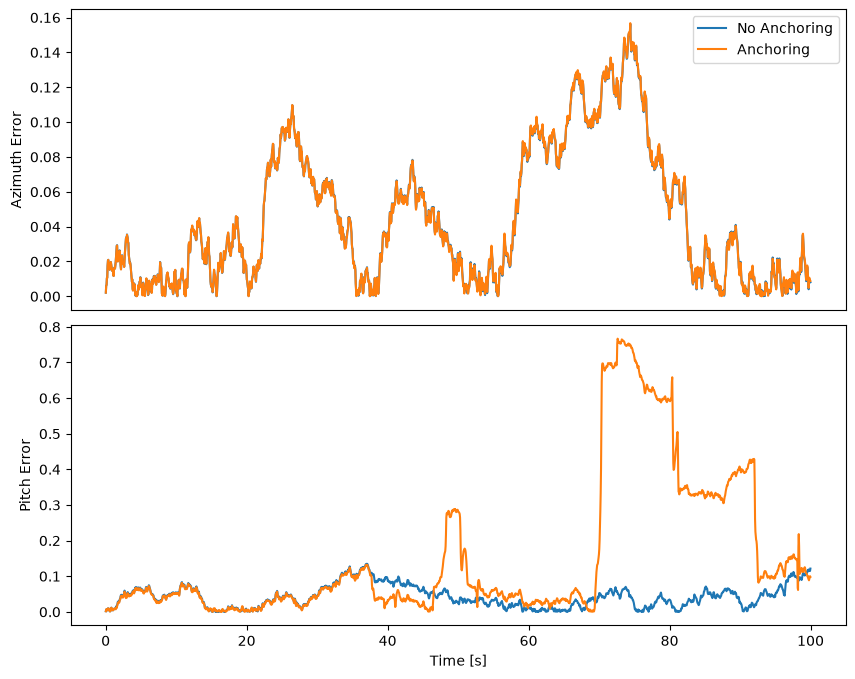

In [5]:
interval = 100

fig, ax = plt.subplots(
    nrows=2,
    figsize=(10, 8),
    sharex=True,
    # height_ratios=(1, 0.3, 1, 0.3),
    gridspec_kw={"hspace": (0.05)},
)
for angle_iter, angle in enumerate(["Azimuth", "Pitch"]):
    anchored_error = angular_error(
        recording_anchor["decoded_angle"][:, angle_iter],
        bat_flight["dir_torus"][:, angle_iter],
    )
    error = angular_error(
        recording["decoded_angle"][:, angle_iter],
        bat_flight["dir_torus"][:, angle_iter],
    )
    ax[1 * angle_iter].plot(
        smooth_ts(bat_flight["time"], interval),
        np.abs(smooth_ts(error, interval)),
        label="No Anchoring",
    )
    ax[1 * angle_iter].plot(
        smooth_ts(bat_flight["time"], interval),
        np.abs(smooth_ts(anchored_error, interval)),
        label="Anchoring",
    )
    ax[1 * angle_iter].set_ylabel(angle + " Error")
    # ax[2 * angle_iter + 1].set_ylabel(angle)
    # ax[2 * angle_iter + 1].plot(
    #     bat_flight["time"],
    #     bat_flight["dir_torus"][:, angle_iter] / np.pi,
    #     color="black",
    # )

for axis_iter in range(len(ax) - 1):
    ax[axis_iter].get_xaxis().set_visible(False)


ax[0].legend()
ax[-1].set_xlabel("Time [s]")
# fig.tight_layout()
fig.savefig(os.path.join(PLOTS_DIR, "bat_flight_anchoring_effect.png"))

Text(0.5, 1.0, 'Conjunctive')

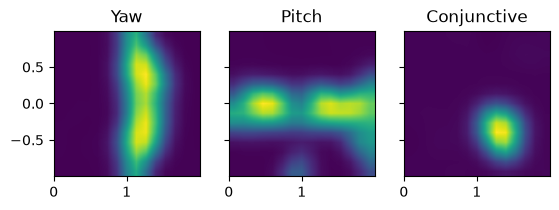

In [6]:
from grid_cells.plot_tools import activity_map

cell_index = 1
fig, ax = plt.subplots(ncols=3, sharey=True)
activity, counts, direction_edges = activity_map(
    bat_flight["dir_torus"], recording_anchor["yaw_cells"][:, 100], nbins=15, sigma=1
)
ax[0].imshow(
    activity.T,
    extent=(
        direction_edges[0][0] / np.pi,
        direction_edges[0][-1] / np.pi,
        direction_edges[1][0] / np.pi,
        direction_edges[1][-1] / np.pi,
    ),
    origin="lower",
    interpolation="bilinear",
)
ax[0].set_title("Yaw")
activity, counts, direction_edges = activity_map(
    bat_flight["dir_torus"],
    recording_anchor["pitch_cells"][:, cell_index],
    nbins=15,
    sigma=1,
)

ax[1].imshow(
    activity.T,
    extent=(
        direction_edges[0][0] / np.pi,
        direction_edges[0][-1] / np.pi,
        direction_edges[1][0] / np.pi,
        direction_edges[1][-1] / np.pi,
    ),
    origin="lower",
    interpolation="bilinear",
)
ax[1].set_title("Pitch")

activity, counts, direction_edges = activity_map(
    bat_flight["dir_torus"],
    recording_anchor["conj_cells"][:, cell_index],
    nbins=15,
    sigma=1,
)
ax[2].imshow(
    activity.T,
    extent=(
        direction_edges[0][0] / np.pi,
        direction_edges[0][-1] / np.pi,
        direction_edges[1][0] / np.pi,
        direction_edges[1][-1] / np.pi,
    ),
    origin="lower",
    interpolation="bilinear",
)
ax[2].set_title("Conjunctive")

In [7]:
recording_anchor["conj_cells"].max(), recording_anchor[
    "pitch_cells"
].max(), recording_anchor["yaw_cells"].max()

(np.float64(1.0139983348942412),
 np.float64(1.4475751736932498),
 np.float64(0.8793389244045584))

In [8]:
raise ValueError("pause")

ValueError: pause

In [ ]:
from matplotlib.animation import FuncAnimation, FFMpegWriter

plt.rcParams["animation.ffmpeg_path"] = "/opt/homebrew/bin/ffmpeg"
pitch_cells = recording_anchor["pitch_cells"]
step = 125
frame_indices = np.arange(0, len(pitch_cells) / 2, step, dtype=int)

n_cells = pitch_cells.shape[1]
true_pitch = bat_flight["dir_torus"][:, 1]
true_pitch_index = ((-true_pitch) % (2 * np.pi)) / (2 * np.pi) * (n_cells - 1)
duplicate_pitch = (np.pi - true_pitch) % (2 * np.pi)
duplicate_pitch_index = ((-duplicate_pitch) % (2 * np.pi)) / (2 * np.pi) * (n_cells - 1)


y_min, y_max = np.percentile(pitch_cells[::step], [1, 99])
margin = 0.05 * (y_max - y_min)

fig, ax = plt.subplots(figsize=(10, 4))
(line,) = ax.plot([], [], lw=2, label="Pitch-cell activity")
true_line = ax.axvline(
    0, color="red", linestyle="--", lw=2, label="True pitch position"
)
duplicate_line = ax.axvline(
    0, color="green", linestyle="--", lw=2, label="Duplicate pitch position"
)
time_text = ax.text(0.02, 0.95, "", transform=ax.transAxes)

ax.set_xlim(0, n_cells - 1)
ax.set_ylim(y_min - margin, y_max + margin)
ax.set_xlabel("Pitch cell index")
ax.set_ylabel("Activity")
ax.set_title("Pitch-cell activity")
ax.legend()


def update(frame):
    index = frame_indices[frame]
    line.set_data(np.arange(n_cells), pitch_cells[index])
    true_line.set_xdata([true_pitch_index[index], true_pitch_index[index]])
    duplicate_line.set_xdata(
        [duplicate_pitch_index[index], duplicate_pitch_index[index]]
    )
    time_text.set_text(f"Time: {bat_flight['time'][index]:.2f} s")
    return line, true_line, duplicate_line, time_text


pitch_animation = FuncAnimation(
    fig,
    update,
    frames=len(frame_indices),
    interval=40,
    blit=True,
)
FFwriter = FFMpegWriter(fps=25)
pitch_animation.save(
    os.path.join(PLOTS_DIR, "bat_flight_pitch_attractor.mp4"), writer=FFwriter
)

In [ ]:
pitch_cells = recording_anchor["yaw_cells"]
step = 125
frame_indices = np.arange(0, len(pitch_cells) / 2, step, dtype=int)

n_cells = pitch_cells.shape[1]
true_pitch = bat_flight["dir_torus"][:, 0]
true_pitch_index = ((-true_pitch) % (2 * np.pi)) / (2 * np.pi) * (n_cells - 1)
duplicate_pitch = (np.pi + true_pitch) % (2 * np.pi)
duplicate_pitch_index = ((-duplicate_pitch) % (2 * np.pi)) / (2 * np.pi) * (n_cells - 1)


y_min, y_max = np.percentile(pitch_cells[::step], [1, 99])
margin = 0.05 * (y_max - y_min)

fig, ax = plt.subplots(figsize=(10, 4))
(line,) = ax.plot([], [], lw=2, label="Yaw-cell activity")
true_line = ax.axvline(0, color="red", linestyle="--", lw=2, label="True Yaw position")
duplicate_line = ax.axvline(
    0, color="green", linestyle="--", lw=2, label="Duplicate Yaw position"
)
time_text = ax.text(0.02, 0.95, "", transform=ax.transAxes)

ax.set_xlim(0, n_cells - 1)
ax.set_ylim(y_min - margin, y_max + margin)
ax.set_xlabel("Yaw cell index")
ax.set_ylabel("Activity")
ax.set_title("Yaw-cell activity")
ax.legend()


def update(frame):
    index = frame_indices[frame]
    line.set_data(np.arange(n_cells), pitch_cells[index])
    true_line.set_xdata([true_pitch_index[index], true_pitch_index[index]])
    duplicate_line.set_xdata(
        [duplicate_pitch_index[index], duplicate_pitch_index[index]]
    )
    time_text.set_text(f"Time: {bat_flight['time'][index]:.2f} s")
    return line, true_line, duplicate_line, time_text


pitch_animation = FuncAnimation(
    fig,
    update,
    frames=len(frame_indices),
    interval=40,
    blit=True,
)
FFwriter = FFMpegWriter(fps=25)

pitch_animation.save(
    os.path.join(PLOTS_DIR, "bat_flight_yaw_attractor.mp4"), writer=FFwriter
)